# TF-IDF Analyses

### RIGHT NOW AS IS, TF-IDF IS VECTORIZED ACROSS EVERY DOCUMENT ACROSS EVERY YEAR. 
### THAT IS NOT WHAT I SHOULD BE DOING. IT SCREWS UP THE WEIGHTS. 
### I SHOULD VECTORIZE ACROSS YEAR OR DOCUMENT.

### Import and Install Packages

In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("TFIDF").getOrCreate()

# count vectorizer
# then do idf for tf-idf scores

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import mannwhitneyu
from tqdm import tqdm
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import nltk
from pyspark.sql import functions as F
from pyspark.ml.functions import vector_to_array

import os

In [37]:
awards_data_cleaned = spark.read \
    .option("header", True) \
    .option("multiLine", True) \
    .option("quote", '"') \
    .option("escape", '"') \
    .option("delimiter", ",") \
    .csv("awards_data_cleaned.csv")

In [38]:
awards_data_cleaned.select("Year").distinct().show()

+----+
|Year|
+----+
|2016|
|2020|
|2019|
|2017|
|2018|
|2022|
|2025|
|2023|
|2021|
|2024|
+----+



In [39]:
def clean_missing_abstracts(df):
    """
    Prints summary of missing values in the 'Abstract' column before and after dropping them.
    Returns a cleaned DataFrame with missing abstracts removed.
    """
    total_before = df.count()
    missing_before = df.filter(df["Abstract"].isNull()).count()
    print(f"🕵️‍♂️ Before cleaning: {missing_before} missing out of {total_before} total rows.")

    df_cleaned = df.dropna(subset=["Abstract"])
    print("Dropped rows with missing abstracts.")

    total_after = df_cleaned.count()
    missing_after = df_cleaned.filter(df_cleaned["Abstract"].isNull()).count()
    print(f"After cleaning: {missing_after} missing out of {total_after} total rows.")

    return df_cleaned

awards_data_clean = clean_missing_abstracts(awards_data_cleaned)



🕵️‍♂️ Before cleaning: 3 missing out of 49954 total rows.
✅ Dropped rows with missing abstracts.
📊 After cleaning: 0 missing out of 49951 total rows.


In [ ]:
# create and fix tf-idf vector
from pyspark.ml.feature import Tokenizer
from pyspark.ml.feature import CountVectorizer


tokenizer = Tokenizer(inputCol="Abstract", outputCol="words_token")
awards_tokenized = tokenizer.transform(awards_data_clean)

from pyspark.ml.feature import StopWordsRemover

remover = StopWordsRemover(inputCol="words_token", outputCol="words_clean")
awards_filtered = remover.transform(awards_tokenized)

from pyspark.ml.feature import HashingTF # NOT HELPFUL BECAUSE YOU CANNOT GET THE WORD NAMES BACK

vectorizer = CountVectorizer(inputCol="words_clean", outputCol="raw_features", vocabSize=150000)
count_vectorizer_model = vectorizer.fit(awards_filtered)
featured_data = count_vectorizer_model.transform(awards_filtered)

from pyspark.ml.feature import IDF

idf = IDF(inputCol="raw_features", outputCol="features")
idf_model = idf.fit(featured_data)
tfidf_data = idf_model.transform(featured_data)

In [41]:
print(count_vectorizer_model.vocabulary[:20])  # first 20 terms


['project', 'research', 'student', 'use', 'datum', 'develop', 'system', 'new', 'model', 'provide', 'study', 'include', 'program', 'science', 'support', 'development', 'also', 'design', 'material', 'work']


In [42]:
tfidf_data.select("Year", "features").show(truncate=False)


+----+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

25/07/25 05:03:30 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


In [43]:
from pyspark.ml.linalg import SparseVector
from pyspark.sql.functions import udf
from pyspark.sql.types import ArrayType, StructType, StructField, IntegerType, FloatType

# Define UDF to unpack the SparseVector
def extract_tfidf(sparse_vec):
    return list(zip(sparse_vec.indices.tolist(), sparse_vec.values.tolist()))

extract_udf = udf(extract_tfidf, ArrayType(StructType([
    StructField("index", IntegerType()),
    StructField("value", FloatType())
])))

# Apply the UDF to extract the TF-IDF values
exploded = tfidf_data.withColumn("tfidf_exploded", extract_udf("features"))
exploded.select("Year", "tfidf_exploded").show(truncate=False)

25/07/25 05:03:34 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


+----+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [44]:
# View top ten words by year
from pyspark.sql.functions import udf, col, explode
from pyspark.sql.types import ArrayType, StructType, StructField, IntegerType, FloatType, StringType

# 1. UDF to extract (index, value) pairs from SparseVector
def extract_tfidf(sparse_vec):
    return list(zip(sparse_vec.indices.tolist(), sparse_vec.values.tolist()))

extract_udf = udf(extract_tfidf, ArrayType(StructType([
    StructField("index", IntegerType()),
    StructField("value", FloatType())
])))

# 2. Apply UDF to get TF-IDF terms
tfidf_terms = tfidf_data.withColumn("tfidf_terms", extract_udf("features"))

# 3. Explode into one row per (index, value)
exploded = tfidf_terms.select("Year", explode("tfidf_terms").alias("term"))
exploded = exploded.select(
    col("Year"),
    col("term.index").alias("term_index"),
    col("term.value").alias("tfidf_score")
)

# 4. Group by Year and term index, sum TF-IDF
yearly_scores = exploded.groupBy("Year", "term_index").sum("tfidf_score")

# 5. Rank within year
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

windowSpec = Window.partitionBy("Year").orderBy(col("sum(tfidf_score)").desc())
ranked = yearly_scores.withColumn("rank", row_number().over(windowSpec))
top_ranked = ranked.filter(col("rank") <= 10)

# 6. Map index back to word using vocab
vocab = count_vectorizer_model.vocabulary  # index -> word

# Use selectExpr + UDF instead of RDD to avoid casting issues
@udf(StringType())
def idx_to_word(index):
    return vocab[index] if index < len(vocab) else None

top_ranked = top_ranked.withColumn("Word", idx_to_word(col("term_index")))

# 7. Select and show nicely
top_ranked.select("Year", "Word", "sum(tfidf_score)").orderBy("Year", col("sum(tfidf_score)").desc()).show(truncate=False, n=100)


25/07/25 05:03:37 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
25/07/25 05:03:56 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


+----+-----------+------------------+
|Year|Word       |sum(tfidf_score)  |
+----+-----------+------------------+
|2016|material   |5535.328313708305 |
|2016|specie     |5274.469056129456 |
|2016|datum      |5219.096509933472 |
|2016|cell       |4826.691211462021 |
|2016|plant      |4821.210090875626 |
|2016|change     |4748.773761749268 |
|2016|system     |4703.561636090279 |
|2016|model      |4691.656934440136 |
|2016|water      |4270.3667759895325|
|2016|study      |4227.272362887859 |
|2017|material   |4784.502442479134 |
|2017|datum      |4395.075783729553 |
|2017|stem       |4328.625123500824 |
|2017|model      |4034.359165072441 |
|2017|system     |4016.99402821064  |
|2017|student    |3945.820679664612 |
|2017|teacher    |3900.342957019806 |
|2017|study      |3803.21533370018  |
|2017|program    |3651.997283935547 |
|2017|engineering|3649.299504995346 |
|2018|datum      |5271.941324234009 |
|2018|material   |4990.869805455208 |
|2018|model      |4336.267598211765 |
|2018|system

25/07/25 05:03:56 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


In [45]:
from pyspark.sql.functions import col, lower, split, explode
from pyspark.sql.functions import countDistinct

# Step 1: Select and lowercase the Abstract column
abstracts_lower = awards_data_clean.select(lower(col("Abstract")).alias("abstract"))

# Step 2: Tokenize by whitespace
abstracts_tokenized = abstracts_lower.select(split(col("abstract"), " ").alias("tokens"))

# Step 3: Explode into one word per row
words_exploded = abstracts_tokenized.select(explode(col("tokens")).alias("word"))

# Step 4: Remove empty strings
words_cleaned = words_exploded.filter(col("word") != "")

# Step 5: Count unique words
unique_word_count = words_cleaned.select("word").distinct().count()

print(f"✅ Number of unique words: {unique_word_count}")


✅ Number of unique words: 139006


### Year to Year Cosine Differences

In [46]:
years = [row["Year"] for row in tfidf_data.select("Year").distinct().collect()]
years = sorted(years)  # optional: sort chronologically


In [47]:
from scipy.sparse import vstack, csr_matrix, save_npz
import numpy as np
import os

years = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
output_dir = "/Users/ryanseely/Documents/Github/reu_nsf"
batch_size = 1000  # Tune this lower if it still crashes

for yr in years:
    print(f"Saving TF-IDF matrix for {yr}")
    
    df_year = tfidf_data.filter(F.col("Year") == yr)
    total_rows = df_year.count()

    vectors = []

    for start in range(0, total_rows, batch_size):
        end = start + batch_size
        print(f"  - Batch {start} to {end}")
        
        batch_df = df_year.withColumn("features_array", vector_to_array("features")) \
                        .rdd.zipWithIndex() \
                        .filter(lambda row_index: start <= row_index[1] < end) \
                        .map(lambda row_index: row_index[0][0]) \
                        .map(lambda v: np.array([float(x) for x in v])) \
                        .collect()

        vectors.extend(batch_df)

    tfidf_matrix = vstack([csr_matrix(vec) for vec in vectors])
    save_npz(os.path.join(output_dir, f"tfidf_{yr}.npz"), tfidf_matrix)


Saving TF-IDF matrix for 2016
  - Batch 0 to 1000


25/07/25 05:04:15 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
25/07/25 05:05:12 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


  - Batch 1000 to 2000


25/07/25 05:06:08 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


  - Batch 2000 to 3000


...

  - Batch 3000 to 4000


25/07/25 05:51:41 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


  - Batch 4000 to 5000


25/07/25 05:52:43 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


  - Batch 5000 to 6000


In [63]:
from sklearn.metrics.pairwise import cosine_distances  # or euclidean_distances
import numpy as np
import pandas as pd
import os
from scipy.sparse import load_npz

# Load average TF-IDF vector per year
years = list(range(2016, 2026))
avg_vectors = {}

for year in years:
    # Load sparse TF-IDF matrix (shape: [num_docs, num_features])
    matrix = load_npz(f"/Users/ryanseely/Documents/Github/reu_nsf/tfidf_{year}.npz")
    
    # Compute average vector across all documents for the year
    avg_vec = matrix.mean(axis=0).A1  # Convert to 1D numpy array
    avg_vectors[year] = avg_vec

# Compute pairwise cosine distances between average vectors
years_sorted = sorted(avg_vectors.keys())
cosine_dists = []

for i in range(len(years_sorted) - 1):
    y1, y2 = years_sorted[i], years_sorted[i + 1]
    v1, v2 = avg_vectors[y1], avg_vectors[y2]
    
    dist = cosine_distances([v1], [v2])[0][0]  # or use euclidean_distances([v1], [v2])[0][0]
    cosine_dists.append({
        "Year1": y1,
        "Year2": y2,
        "Distance": dist  # ← this line was missing
})
    
dist_df = pd.DataFrame(cosine_dists)


In [65]:
import pandas as pd

# Create a labeled DataFrame from the cosine distance matrix
cosine_df = pd.DataFrame(
    cosine_dist_matrix,
    index=years,
    columns=years
)

# Print the DataFrame nicely
print("\nCosine Distance Matrix (Pandas DataFrame):")
print(cosine_df.round(4)) 



Cosine Distance Matrix (Pandas DataFrame):
        2016    2017    2018    2019    2020    2021    2022    2023    2024  \
2016  0.0000  0.0039  0.0103  0.0243  0.0092  0.1200  0.0768  0.0472  0.0245   
2017  0.0039  0.0000  0.0018  0.0090  0.0222  0.1623  0.1107  0.0727  0.0427   
2018  0.0103  0.0018  0.0000  0.0031  0.0351  0.1938  0.1375  0.0933  0.0584   
2019  0.0243  0.0090  0.0031  0.0000  0.0560  0.2382  0.1754  0.1235  0.0829   
2020  0.0092  0.0222  0.0351  0.0560  0.0000  0.0671  0.0350  0.0153  0.0042   
2021  0.1200  0.1623  0.1938  0.2382  0.0671  0.0000  0.0056  0.0229  0.0453   
2022  0.0768  0.1107  0.1375  0.1754  0.0350  0.0056  0.0000  0.0071  0.0202   
2023  0.0472  0.0727  0.0933  0.1235  0.0153  0.0229  0.0071  0.0000  0.0046   
2024  0.0245  0.0427  0.0584  0.0829  0.0042  0.0453  0.0202  0.0046  0.0000   
2025  0.0096  0.0194  0.0305  0.0486  0.0016  0.0783  0.0427  0.0197  0.0058   

        2025  
2016  0.0096  
2017  0.0194  
2018  0.0305  
2019  0.0486  


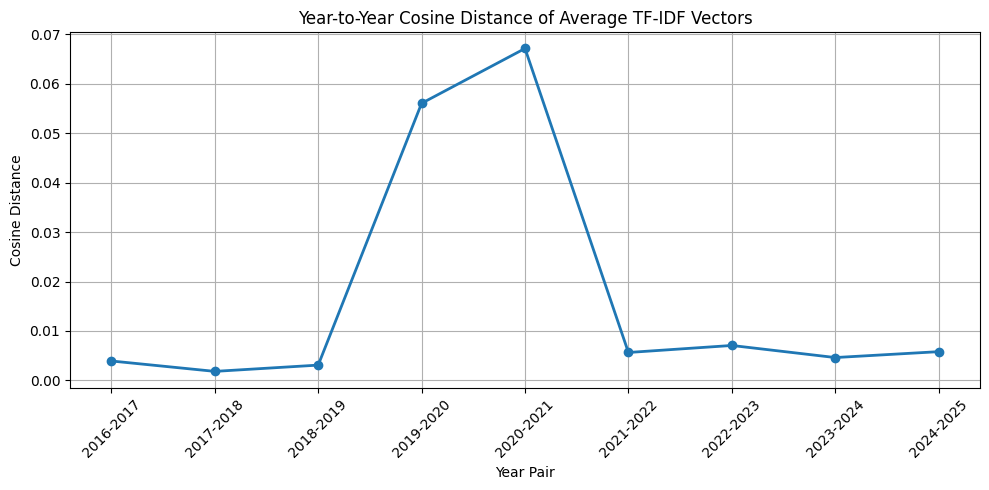

In [66]:
import matplotlib.pyplot as plt

# Create x-axis labels like '2016–2017', '2017–2018', etc.
labels = [f"{int(row['Year1'])}-{int(row['Year2'])}" for _, row in adjacent_pairs.iterrows()]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(labels, adjacent_pairs['CosineDistance'], marker='o', linestyle='-', linewidth=2)

# Styling
plt.title("Year-to-Year Cosine Distance of Average TF-IDF Vectors")
plt.xlabel("Year Pair")
plt.ylabel("Cosine Distance")
plt.xticks(rotation=45)
plt.grid(True)

# Show plot
plt.tight_layout()
plt.show()

### What does this show????

Either, it's an issue with the data

an issue with the TF-IDF analysis

Or it is a pattern, 2020 got crazy and caused a significant difference in its vocabulary/word usage from 2019. Then, 2021's abstracts were also very different from 2020's, but not necessarily different from 2019s? but at the very least, this graph suggests 2021 is very different from 2020, in fact, the difference showing up in 2021 from 2020 is greater than the difference showing up in 2020 from 2019. But after that, 2022 was relatively similar to 2021, 23 similar to 24, and 24 similar to 25.

Then, this might make sense in the idea that vectorizing over multiple year is not the right strategy. But either way, I will probably need a way to control for COVID?

In [55]:
import numpy as np

diff_2020_2019 = np.linalg.norm(avg_matrix[years.index(2020)] - avg_matrix[years.index(2019)])
diff_2021_2020 = np.linalg.norm(avg_matrix[years.index(2021)] - avg_matrix[years.index(2020)])
print("Euclidean difference 2019→2020:", diff_2020_2019)
print("Euclidean difference 2020→2021:", diff_2021_2020)

Euclidean difference 2019→2020: 4.462783014551128
Euclidean difference 2020→2021: 3.657435331467263


In [57]:
from scipy.sparse import load_npz

year = 2020  # repeat for 2019 and 2021
matrix = load_npz(f"tfidf_{year}.npz")
mean_vec = matrix.mean(axis=0).A1
top_indices = mean_vec.argsort()[-10:][::-1]
print("Top words for", year)
print([vocab[i] for i in top_indices])

Top words for 2020
['system', 'develop', 'datum', 'research', 'use', 'student', 'project']


In [87]:
from pyspark.sql.types import NumericType

# Show all non-numeric columns
non_numeric_cols = [f.name for f in tfidf_data.schema.fields if not isinstance(f.dataType, NumericType)]
print(non_numeric_cols)

['AwardNumber', 'Title', 'NSFOrganization', 'Program(s)', 'StartDate', 'LastAmendmentDate', 'PrincipalInvestigator', 'State', 'Organization', 'AwardInstrument', 'ProgramManager', 'EndDate', 'AwardedAmountToDate', 'Co-PIName(s)', 'PIEmailAddress', 'OrganizationStreet', 'OrganizationCity', 'OrganizationState', 'OrganizationZip', 'OrganizationPhone', 'NSFDirectorate', 'ProgramElementCode(s)', 'ProgramReferenceCode(s)', 'ARRAAmount', 'Abstract', 'Year', 'Month', 'words_token', 'words_clean', 'raw_features', 'features']


In [90]:
tfidf_data.printSchema()


root
 |-- AwardNumber: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- NSFOrganization: string (nullable = true)
 |-- Program(s): string (nullable = true)
 |-- StartDate: string (nullable = true)
 |-- LastAmendmentDate: string (nullable = true)
 |-- PrincipalInvestigator: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Organization: string (nullable = true)
 |-- AwardInstrument: string (nullable = true)
 |-- ProgramManager: string (nullable = true)
 |-- EndDate: string (nullable = true)
 |-- AwardedAmountToDate: string (nullable = true)
 |-- Co-PIName(s): string (nullable = true)
 |-- PIEmailAddress: string (nullable = true)
 |-- OrganizationStreet: string (nullable = true)
 |-- OrganizationCity: string (nullable = true)
 |-- OrganizationState: string (nullable = true)
 |-- OrganizationZip: string (nullable = true)
 |-- OrganizationPhone: string (nullable = true)
 |-- NSFDirectorate: string (nullable = true)
 |-- ProgramElementCode(s): string (null

In [92]:
from pyspark.ml.functions import vector_to_array

tfidf_data = tfidf_data.withColumn("tfidf_array", vector_to_array("features"))

In [93]:
tfidf_data.selectExpr("size(tfidf_array) as num_elements").show()

+------------+
|num_elements|
+------------+
|      138881|
|      138881|
|      138881|
|      138881|
|      138881|
|      138881|
|      138881|
|      138881|
|      138881|
|      138881|
|      138881|
|      138881|
|      138881|
|      138881|
|      138881|
|      138881|
|      138881|
|      138881|
|      138881|
|      138881|
+------------+
only showing top 20 rows


25/07/25 06:32:28 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


In [94]:
from pyspark.sql.functions import posexplode

tfidf_exploded = tfidf_data.select("Year", "Abstract", posexplode("tfidf_array").alias("word_index", "tfidf_score"))

In [95]:
tfidf_exploded.show(truncate=False)


+----+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

25/07/25 06:33:40 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


25/07/25 13:00:56 WARN TransportChannelHandler: Exception in connection from /172.20.10.2:50326
java.io.IOException: Operation timed out
	at java.base/sun.nio.ch.SocketDispatcher.read0(Native Method)
	at java.base/sun.nio.ch.SocketDispatcher.read(SocketDispatcher.java:47)
	at java.base/sun.nio.ch.IOUtil.readIntoNativeBuffer(IOUtil.java:330)
	at java.base/sun.nio.ch.IOUtil.read(IOUtil.java:284)
	at java.base/sun.nio.ch.IOUtil.read(IOUtil.java:259)
	at java.base/sun.nio.ch.SocketChannelImpl.read(SocketChannelImpl.java:417)
	at io.netty.buffer.PooledByteBuf.setBytes(PooledByteBuf.java:255)
	at io.netty.buffer.AbstractByteBuf.writeBytes(AbstractByteBuf.java:1132)
	at io.netty.channel.socket.nio.NioSocketChannel.doReadBytes(NioSocketChannel.java:356)
	at io.netty.channel.nio.AbstractNioByteChannel$NioByteUnsafe.read(AbstractNioByteChannel.java:151)
	at io.netty.channel.nio.NioEventLoop.processSelectedKey(NioEventLoop.java:796)
	at io.netty.channel.nio.NioEventLoop.processSelectedKeysOptimiz

In [10]:
from sklearn.metrics.pairwise import cosine_distances

# Compute cosine distances between year vectors
cosine_dists = cosine_distances(yearly_avg.values)

# Convert to a DataFrame for readability
cosine_dists_df = pd.DataFrame(
    cosine_dists,
    index=yearly_avg.index,
    columns=yearly_avg.index
)

cosine_dists_df 

Year,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Year,,,,,,,,,,
2016,0.000000,0.016274,0.014351,0.016941,0.031983,0.029503,0.031016,0.028967,0.042086,0.064943
2017,0.016274,0.000000,0.013103,0.013398,0.026971,0.024627,0.023454,0.023949,0.032963,0.059608
2018,0.014351,0.013103,0.000000,0.011428,0.025118,0.023056,0.021714,0.020432,0.030125,0.053239
2019,0.016941,0.013398,0.011428,0.000000,0.025377,0.020087,0.018172,0.016650,0.024586,0.048718
2020,0.031983,0.026971,0.025118,0.025377,0.000000,0.019637,0.020488,0.023081,0.033527,0.054814
2021,0.029503,0.024627,0.023056,0.020087,0.019637,0.000000,0.012975,0.014820,0.022458,0.046289
2022,0.031016,0.023454,0.021714,0.018172,0.020488,0.012975,0.000000,0.012027,0.018214,0.040889
2023,0.028967,0.023949,0.020432,0.016650,0.023081,0.014820,0.012027,0.000000,0.014562,0.035455
2024,0.042086,0.032963,0.030125,0.024586,0.033527,0.022458,0.018214,0.014562,0.000000,0.027988


### Cosine Distance before new data

In [11]:
years = sorted(cosine_dists_df.index.tolist())

# Collect consecutive year distances
consec_diffs = []

for i in range(len(years) - 1):
    year1 = years[i]
    year2 = years[i + 1]
    dist = cosine_dists_df.loc[year1, year2]

    consec_diffs.append({
        'Year1': year1,
        'Year2': year2,
        'Cosine_Distance': dist
    })

# Convert to DataFrame
consec_diffs_df = pd.DataFrame(consec_diffs)

consec_diffs_df.sort_values('Cosine_Distance', ascending=False)


,Year1,Year2,Cosine_Distance
8,2024,2025,0.027988
3,2019,2020,0.025377
4,2020,2021,0.019637
0,2016,2017,0.016274
7,2023,2024,0.014562
1,2017,2018,0.013103
5,2021,2022,0.012975
6,2022,2023,0.012027
2,2018,2019,0.011428


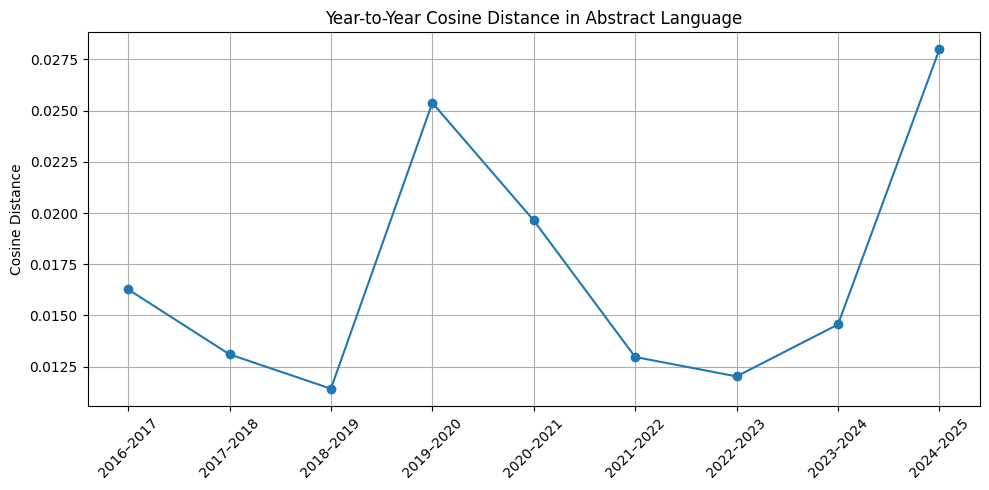

In [12]:
import matplotlib.pyplot as plt

# Create a label for the x-axis like "2016–2017", "2017–2018", ...
consec_diffs_df['Year_Pair'] = consec_diffs_df['Year1'].astype(str) + '–' + consec_diffs_df['Year2'].astype(str)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(consec_diffs_df['Year_Pair'], consec_diffs_df['Cosine_Distance'], marker='o', linestyle='-')
plt.xticks(rotation=45)
plt.ylabel('Cosine Distance')
plt.title('Year-to-Year Cosine Distance in Abstract Language')
plt.grid(True)
plt.tight_layout()
plt.show()

### Statistically Testing Year-to-Year Changes in TF-IDF Scores

Using Mann-Whitney U Tests to compare the TF-IDF distributions of each word between two consecutive years - attempting to answer if those distributions differ significantly.

In [69]:
# Preprocess

from scipy.stats import mannwhitneyu
from pyspark.sql.functions import col
import pandas as pd

# Get list of word columns (excluding 'Year')
word_columns = [col for col in tfidf_data.columns if col != 'Year']

# Get sorted list of years
years = sorted([row['Year'] for row in tfidf_data.select('Year').distinct().collect()])

# Initialize result list
results = []

for i in range(len(years) - 1):
    year1 = years[i]
    year2 = years[i + 1]

    # Filter PySpark DataFrames for each year
    df1 = tfidf_data.filter(col("Year") == year1)
    df2 = tfidf_data.filter(col("Year") == year2)

    # Convert to Pandas for each word's test
    pdf1 = df1.select(*word_columns).toPandas()
    pdf2 = df2.select(*word_columns).toPandas()

    for word in word_columns:
        pdf1[word] = pd.to_numeric(pdf1[word], errors='coerce')
        pdf2[word] = pd.to_numeric(pdf2[word], errors='coerce')
        vec1 = pdf1[word].dropna()
        vec2 = pdf2[word].dropna()

        # Only test if at least one of the distributions is nonzero
        if (vec1 > 0).mean() + (vec2 > 0).mean() == 0:
            continue

        try:
            stat, p = mannwhitneyu(vec1, vec2, alternative='two-sided')
            prop1 = (vec1 > 0).mean()
            prop2 = (vec2 > 0).mean()
            results.append({
                'Year1': year1,
                'Year2': year2,
                'word': word,
                'U_stat': stat,
                'p_value': p,
                'prop1': prop1,
                'prop2': prop2,
                'effect_size': prop2 - prop1
            })
        except ValueError:
            continue


25/07/25 06:17:12 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
25/07/25 06:17:14 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
25/07/25 06:17:19 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
25/07/25 06:17:21 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
25/07/25 06:17:25 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
25/07/25 06:17:27 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
25/07/25 06:17:32 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
25/07/25 06:17:34 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
25/07/25 06:17:40 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
25/07/25 06:17:42 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
25/07/25 06:17:46 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
25/07/25 06:17:48 WARN DAGScheduler: Broadcasting larg

In [72]:
import sys
size_bytes = sys.getsizeof(results)
size_mb = size_bytes / (1024 * 1024)
print(f"Estimated size of results list: {size_mb:.2f} MB")

Estimated size of results list: 0.00 MB


In [73]:
# put the Mann Whitney U test results into a DataFrame
results_df = pd.DataFrame(results)

# Add significance flag, using FDR correction
from statsmodels.stats.multitest import multipletests

results_df['FDR_corrected'], results_df['q_value'], _, _ = multipletests(results_df['p_value'], method='fdr_bh')

results_df['significant'] = results_df['q_value'] < 0.05


In [74]:
results_df.to_csv("results_df.csv", index=False)

In [75]:
summary_df = (
    results_df.groupby(['Year1', 'Year2'])['significant']
    .sum()
    .reset_index()
    .rename(columns={'significant': 'num_significant_words'})
    .sort_values('num_significant_words', ascending=False)
)

In [76]:
summary_df
# 2024-2025 has greatest number of shifts

,Year1,Year2,num_significant_words
8,2024,2025,4
0,2016,2017,3
1,2017,2018,3
3,2019,2020,3
4,2020,2021,3
6,2022,2023,3
2,2018,2019,2
5,2021,2022,2
7,2023,2024,2


In [83]:
results_df[results_df['significant'] == True]

,Year1,Year2,word,U_stat,p_value,prop1,prop2,effect_size,FDR_corrected,q_value,significant
0,2016,2017,AwardNumber,102335.0,0.000000e+00,1.000000,1.000000,0.000000,True,0.000000e+00,True
4,2016,2017,ProgramReferenceCode(s),591764.0,2.009766e-02,0.999167,1.000000,0.000833,True,4.341094e-02,True
5,2016,2017,Month,10716707.0,3.345599e-26,1.000000,1.000000,0.000000,True,1.642385e-25,True
6,2017,2018,AwardNumber,191126.0,0.000000e+00,1.000000,1.000000,0.000000,True,0.000000e+00,True
10,2017,2018,ProgramReferenceCode(s),454288.0,4.250272e-03,1.000000,1.000000,0.000000,True,1.043249e-02,True
11,2017,2018,Month,11714387.0,1.202825e-13,1.000000,1.000000,0.000000,True,5.412715e-13,True
12,2018,2019,AwardNumber,166941.0,0.000000e+00,1.000000,1.000000,0.000000,True,0.000000e+00,True
17,2018,2019,Month,13104131.5,2.839210e-05,1.000000,1.000000,0.000000,True,9.582334e-05,True
18,2019,2020,AwardNumber,106985.0,0.000000e+00,1.000000,1.000000,0.000000,True,0.000000e+00,True
22,2019,2020,ProgramReferenceCode(s),598006.0,2.825816e-04,1.000000,1.000000,0.000000,True,8.477449e-04,True


In [77]:
# words that changed significantly in 2024 to 2025
sig_words_24_25 = (
    results_df[
        (results_df['Year1'] == 2024) &
        (results_df['Year2'] == 2025) &
        (results_df['significant'] == True)
    ][['word', 'p_value', 'q_value', 'effect_size']]
    .sort_values('q_value')  # or sort by 'effect_size' if you prefer
)

sig_words_24_25

,word,p_value,q_value,effect_size


In [26]:
# words that changed significantly in 2020 to 2021
sig_words_20_21 = (
    results_df[
        (results_df['Year1'] == 2020) &
        (results_df['Year2'] == 2021) &
        (results_df['significant'] == True)
    ][['word', 'p_value', 'q_value', 'effect_size']]
    .sort_values('q_value')  # or sort by 'effect_size' if you prefer
)

sig_words_20_21

,word,p_value,q_value,effect_size
295993,covid,2.062936e-21,1.315543e-16,0.056186
329593,pandemic,2.735200e-19,1.585680e-14,0.049930
315983,june,5.525318e-09,7.340661e-05,-0.023854
308357,grant,8.771192e-09,1.096750e-04,-0.047850
334263,project,1.437149e-08,1.666319e-04,0.059029
343272,sponsoring,1.642246e-08,1.837311e-04,-0.020621
306838,fy,1.642246e-08,1.837311e-04,-0.020621
284690,aim,2.486942e-08,2.688022e-04,0.087695
294819,conference,4.423725e-08,4.550044e-04,-0.053850
313033,impactcommercial,6.063373e-08,5.817482e-04,0.042670


### TF-IDF Visualizations

In [27]:
years = sorted(tfidf_df['Year'].unique())
years

[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

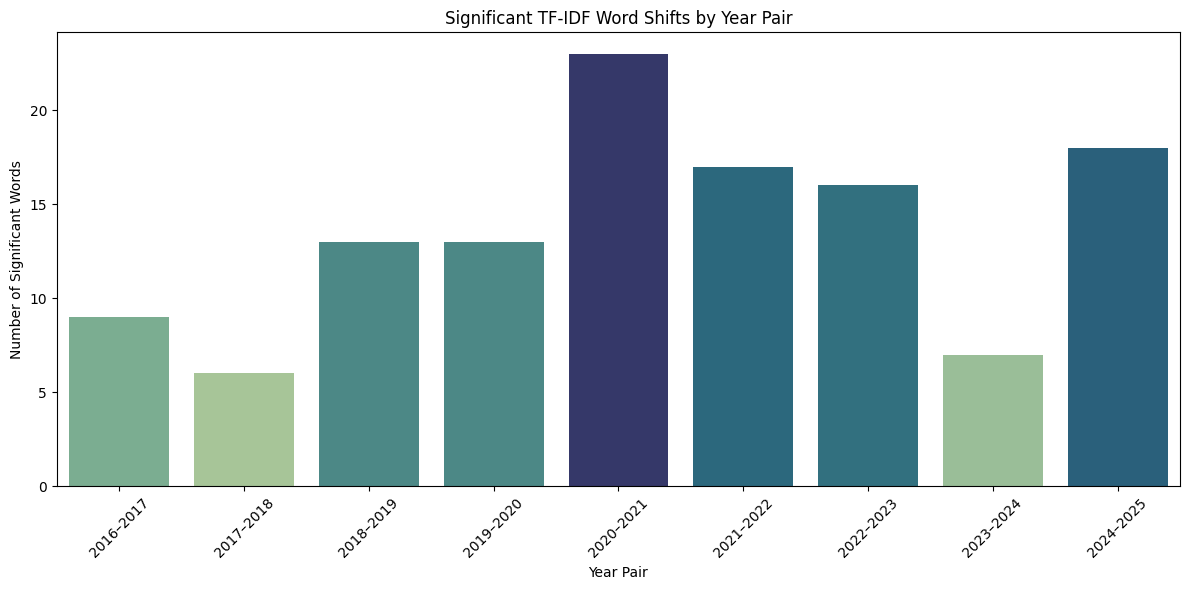

In [28]:
# Filter for significant results
sig_df = results_df[results_df['significant']].copy()

# Create year-pair label like "2016–2017"
sig_df['year_pair'] = sig_df['Year1'].astype(str) + '–' + sig_df['Year2'].astype(str)

# Count significant words by year-pair
pair_counts = (
    sig_df.groupby('year_pair')
    .size()
    .reset_index(name='num_significant_words')
)

import seaborn as sns
import matplotlib.pyplot as plt

# Create the barplot with color intensity based on bar height
plt.figure(figsize=(12, 6))
sns.barplot(
    data=pair_counts,
    x='year_pair',
    y='num_significant_words',
    hue='num_significant_words',
    palette='crest',  # try 'crest' or 'flare'
    dodge=False,
)

plt.xticks(rotation=45)
plt.xlabel('Year Pair')
plt.ylabel('Number of Significant Words')
plt.title('Significant TF-IDF Word Shifts by Year Pair')
plt.legend([],[], frameon=False)  # Remove legend since color = height
plt.tight_layout()
plt.show()

### Should I normalize?
 
 Let's check

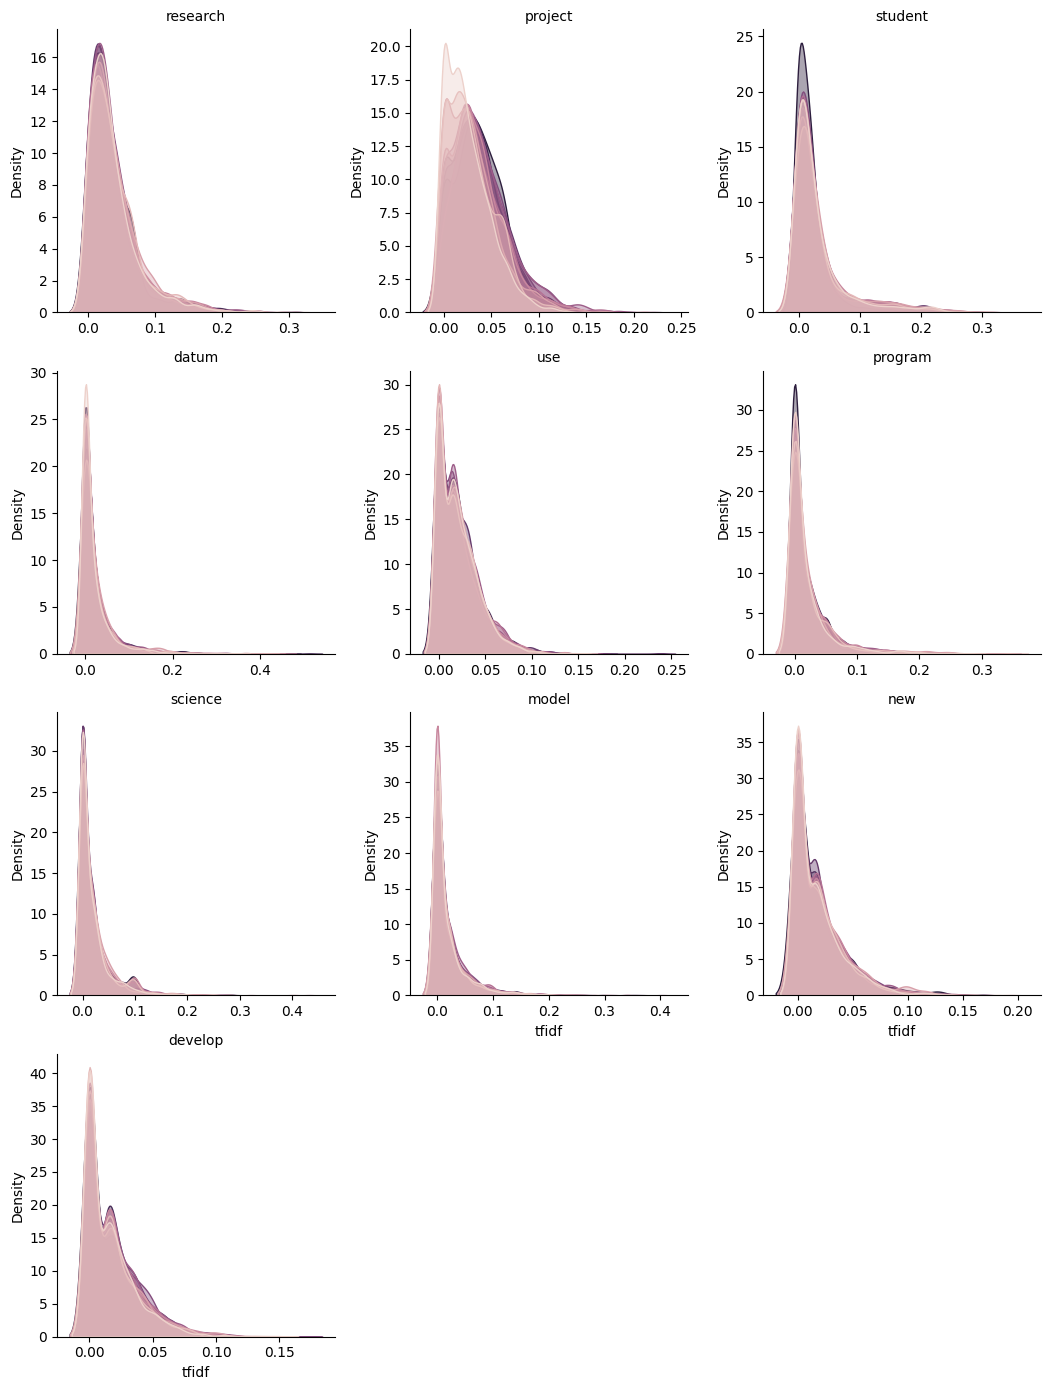

In [83]:
top_words = tfidf_df[word_cols].mean().sort_values(ascending=False).head(10).index.tolist()

tfidf_melted = tfidf_df[['Year'] + top_words].melt(id_vars='Year', var_name='word', value_name='tfidf')

import seaborn as sns
import matplotlib.pyplot as plt

# Plot one density plot per word, colored by year
g = sns.FacetGrid(tfidf_melted, col='word', col_wrap=3, height=3.5, sharex=False, sharey=False)
g.map_dataframe(sns.kdeplot, x='tfidf', hue='Year', common_norm=False, fill=True, alpha=0.4)
g.add_legend()
g.set_titles(col_template="{col_name}")
plt.tight_layout()
plt.show()

# so maybe i should normalize

### Normalization Code - IF I need to normalize

In [ ]:
# Exclude 'Year'
word_cols = tfidf_df.columns.drop('Year')

from sklearn.preprocessing import StandardScaler

tfidf_zscore = []

for year, group in tfidf_df.groupby('Year'):
    X = group[word_cols].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Rebuild a DataFrame for this year
    df_scaled = pd.DataFrame(X_scaled, columns=word_cols)
    df_scaled['Year'] = year
    tfidf_zscore.append(df_scaled)

# Combine all years back into one DataFrame
tfidf_zscore = pd.concat(tfidf_zscore, ignore_index=True)

In [85]:
from scipy.stats import mannwhitneyu

def run_stat_tests(df, year1, year2):
    group1 = df[df['Year'] == year1][word_cols]
    group2 = df[df['Year'] == year2][word_cols]
    
    results = []

    for word in word_cols:
        try:
            stat, p = mannwhitneyu(group1[word], group2[word], alternative='two-sided')
            med1 = group1[word].median()
            med2 = group2[word].median()
            effect = med2 - med1
            results.append({'word': word, 'p_value': p, 'effect_size': effect})
        except ValueError:
            continue
    
    return pd.DataFrame(results)

In [86]:
results_raw = run_stat_tests(tfidf_df, 2024, 2025)
results_norm = run_stat_tests(tfidf_zscore, 2024, 2025)

In [87]:
from statsmodels.stats.multitest import multipletests

# FDR correction
results_raw['q'] = multipletests(results_raw['p_value'], method='fdr_bh')[1]
results_norm['q'] = multipletests(results_norm['p_value'], method='fdr_bh')[1]

# Flag significant
results_raw['significant'] = results_raw['q'] < 0.05
results_norm['significant'] = results_norm['q'] < 0.05

# Compare counts
print("Raw TF-IDF: ", results_raw['significant'].sum(), "significant words")
print("Z-score TF-IDF: ", results_norm['significant'].sum(), "significant words")

Raw TF-IDF:  20 significant words
Z-score TF-IDF:  24270 significant words


In [88]:
sig_words_raw = set(results_raw[results_raw['significant']]['word'])
sig_words_norm = set(results_norm[results_norm['significant']]['word'])

print("Overlap:", len(sig_words_raw & sig_words_norm))
print("Only in raw:", len(sig_words_raw - sig_words_norm))
print("Only in normalized:", len(sig_words_norm - sig_words_raw))

Overlap: 20
Only in raw: 0
Only in normalized: 24250


In [ ]:
import seaborn as sns
sns.histplot(results_raw['p_value'], bins=50, color='blue', label='raw', kde=True)
sns.histplot(results_norm['p_value'], bins=50, color='red', label='zscore', kde=True)
plt.legend()

### 2025-2025 Deep Dive

In [29]:
subset_2425 = results_df[
    (results_df['Year1'] == 2024) & 
    (results_df['Year2'] == 2025) & 
    (results_df['significant'] == True)
]

subset_2425

,Year1,Year2,word,U_stat,p_value,prop1,prop2,effect_size,FDR_corrected,q_value,significant
574661,2024,2025,career,668938.5,5.086904e-06,0.287938,0.205772,-0.082166,True,2.922468e-02,True
576562,2024,2025,climate,662756.5,1.014389e-09,0.122568,0.043915,-0.078653,True,1.577757e-05,True
582217,2024,2025,development,692652.5,6.112104e-08,0.533722,0.412798,-0.120924,True,5.817482e-04,True
583311,2024,2025,diverse,675631.0,8.320436e-09,0.224384,0.125471,-0.098913,True,1.061195e-04,True
585919,2024,2025,engineering,672967.5,1.197683e-07,0.242542,0.150565,-0.091978,True,1.004957e-03,True
586413,2024,2025,equity,635237.0,3.282853e-07,0.035019,0.001255,-0.033765,True,2.553035e-03,True
587660,2024,2025,faculty,661762.5,1.002365e-07,0.151102,0.072773,-0.078330,True,8.637999e-04,True
588129,2024,2025,fellowship,586331.0,1.087427e-14,0.003243,0.048934,0.045691,True,3.852537e-10,True
590262,2024,2025,fy,591357.0,1.775973e-14,0.000000,0.037641,0.037641,True,5.662725e-10,True
596739,2024,2025,inclusive,638671.0,2.761051e-06,0.051881,0.012547,-0.039334,True,1.760733e-02,True


/var/folders/ms/yvnygwhs3jq6kw556d3s72lc0000gn/T/ipykernel_46269/4014360140.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm_r')


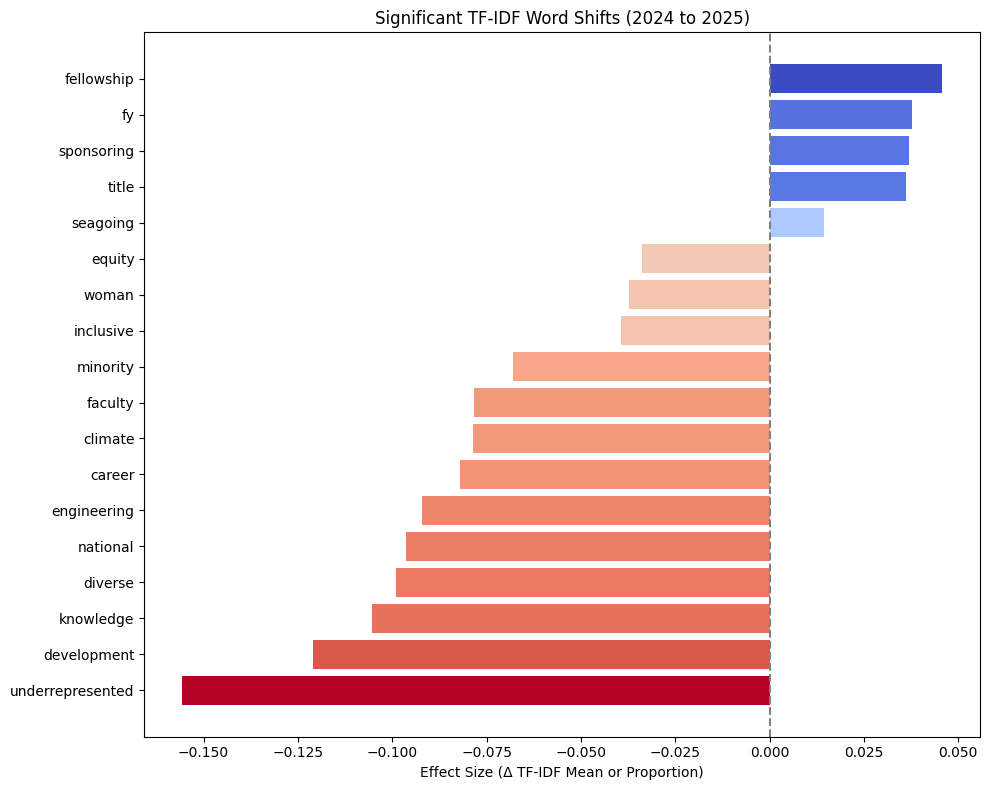

In [34]:
# Sort the data by effect size
subset_sorted = subset_2425.sort_values(by='effect_size')

# Normalize the effect size values to [0, 1] for color mapping
norm = mcolors.TwoSlopeNorm(vmin=subset_sorted['effect_size'].min(),
                            vcenter=0,
                            vmax=subset_sorted['effect_size'].max())

# Choose a diverging colormap
cmap = cm.get_cmap('coolwarm_r')

# Map effect sizes to colors
colors = cmap(norm(subset_sorted['effect_size']))

# Plot
plt.figure(figsize=(10, 8))
bars = plt.barh(subset_sorted['word'], subset_sorted['effect_size'], color=colors)

plt.axvline(0, color='gray', linestyle='--')
plt.xlabel('Effect Size (Δ TF-IDF Mean or Proportion)')
plt.title('Significant TF-IDF Word Shifts (2024 to 2025)')
plt.tight_layout()
plt.show()